## Imports

In [161]:
import mesmer
import model
import model_analysis

import importlib
import matplotlib.pyplot as plt
import xarray as xr

import numpy as np

import cartopy.crs as ccrs



### Updates (temp)

In [162]:
importlib.reload(model.stats);
importlib.reload(model.shape_data);
importlib.reload(model.transform);



## Load Data

In [163]:
is_local_data = True
month_idx = 4
safe = False

In [164]:
mrsol_ds_for_mean = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=1)
mrsol_ds_for_mean = model.shape_data.prune_group_ds_timespan(mrsol_ds_for_mean,Month_idx=month_idx).drop_vars("depth_bnds")

mrsol_ds_for_var = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=2)
mrsol_ds_for_var = model.shape_data.prune_group_ds_timespan(mrsol_ds_for_var,Month_idx=month_idx).drop_vars("depth_bnds")

mrsol_ds_for_skew = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=3)
mrsol_ds_for_skew = model.shape_data.prune_group_ds_timespan(mrsol_ds_for_skew,Month_idx=month_idx).drop_vars("depth_bnds")

#Wenn man sicher gehen will, das der Predictor die testdaten nicht kennen soll, kann man die testdaten auch erst nach dem Calibrieren berechnen
mrsol_ds_for_test = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=4)
mrsol_ds_for_test = model.shape_data.prune_group_ds_timespan(mrsol_ds_for_test,Month_idx=month_idx).drop_vars("depth_bnds")

In [165]:
tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=1)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=1)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)

input_ds_for_mean = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=2)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=2)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)

input_ds_for_var = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=3)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=3)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)

input_ds_for_skew = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=4)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=4)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)

input_ds_for_test = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")


### Mask and Stack Data

In [166]:
mrsol_masked_ds_for_mean, chunk_mask, detail_mask_mean = model.mask.mask_nonpositiv_height_chunks(mrsol_ds_for_mean)
input_masked_ds_for_mean = model.mask.mask_mask(input_ds_for_mean,chunk_mask)

mrsol_masked_ds_for_var, chunk_mask_var, detail_mask_var = model.mask.mask_nonpositiv_height_chunks(mrsol_ds_for_var)
input_masked_ds_for_var = model.mask.mask_mask(input_ds_for_var,chunk_mask)

mrsol_masked_ds_for_skew, chunk_mask_skew, detail_mask_skew = model.mask.mask_nonpositiv_height_chunks(mrsol_ds_for_skew)
input_masked_ds_for_skew = model.mask.mask_mask(input_ds_for_skew,chunk_mask)

mrsol_masked_ds_for_test, chunk_mask_test, detail_mask_test= model.mask.mask_nonpositiv_height_chunks(mrsol_ds_for_test)
input_masked_ds_for_test = model.mask.mask_mask(input_ds_for_test,chunk_mask)

In [167]:
#The chunk_mask schould all be the same, this is important that there are no shape problems in the regressions, you can test this with  
#(chunk_mask != chunk_mask_2).sum(),#(chunk_mask != chunk_mask_1).sum(),
#The chunk_mask is used, that the regression can predict a depth.size vector at each gridcell, the masks: detail_mask_mean, detail_mask_var and detail_mask_test are later used to determan which points are real predictions and witch where just placeholders to let the regression run smoothly.

In [168]:
mrsol_stack_ds_for_mean = mesmer.grid.stack_lat_lon(mrsol_masked_ds_for_mean)
mrsol_stack_ds_for_var = mesmer.grid.stack_lat_lon(mrsol_masked_ds_for_var)
mrsol_stack_ds_for_skew = mesmer.grid.stack_lat_lon(mrsol_masked_ds_for_skew)
mrsol_stack_ds_for_test = mesmer.grid.stack_lat_lon(mrsol_masked_ds_for_test)
input_stack_ds_for_mean = mesmer.grid.stack_lat_lon(input_masked_ds_for_mean)
input_stack_ds_for_var = mesmer.grid.stack_lat_lon(input_masked_ds_for_var)
input_stack_ds_for_skew = mesmer.grid.stack_lat_lon(input_masked_ds_for_skew)
input_stack_ds_for_test = mesmer.grid.stack_lat_lon(input_masked_ds_for_test)

### Transform Data

In [169]:
mrsol_t_for_mean = model.transform.none_Transform_ds(mrsol_stack_ds_for_mean)
mrsol_t_for_var = model.transform.none_Transform_ds(mrsol_stack_ds_for_var)
mrsol_t_for_skew = model.transform.none_Transform_ds(mrsol_stack_ds_for_skew)
mrsol_t_for_test = model.transform.none_Transform_ds(mrsol_stack_ds_for_test)

### Linaer Regression of the mean

In [170]:
mean_predictors = input_stack_ds_for_mean
mean_target_da = mrsol_t_for_mean.mrsol

In [171]:
LinReg_mean = model.stats._parallel_linear_regression.ParLinearRegression()

In [172]:
LinReg_mean.fit(predictors=mean_predictors, target=mean_target_da,location_dim="gridcell", regr_dim="time")

In [173]:
#LinReg_mean.params

### Compute Residuals for the variance

Hier wäre die meinung einen neuen Run zu verwenden, die frage ist ob sich die variance durch das fehlen des runs zu tief ausfällt. Overfitting korrektur mit 1/(1-param/n_samples)^2? (SPäter probieren)

In [174]:
var_predictors = input_stack_ds_for_var
var_target_ds = mrsol_t_for_var

In [175]:
residuals_t = LinReg_mean.residuals(var_predictors, var_target_ds)

In [176]:
residuals_t

<xarray.Dataset> Size: 3MB
Dimensions:    (depth: 5, time: 165, gridcell: 378)
Coordinates:
  * depth      (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
  * time       (time) datetime64[ns] 1kB 1850-04-30 1851-04-30 ... 2014-04-30
    lat        (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75 78.75
    lon        (gridcell) float64 3kB 288.0 288.0 288.0 ... 270.0 279.0 297.0
    height     float64 8B 2.0
Dimensions without coordinates: gridcell
Data variables:
    residuals  (time, depth, gridcell) float64 2MB 0.06796 0.1674 ... 2.711e-19

### Linear Regression of the Variance

In [177]:
LinReg_variance = model.stats._parallel_linear_regression.ParLinearRegression()

In [178]:
LinReg_variance.fit(predictors=var_predictors, target=(residuals_t.residuals)**2,location_dim="gridcell", regr_dim="time")

### Compute skewness samples

In [179]:
skew_predictors = input_stack_ds_for_skew
skew_target_ds = mrsol_t_for_skew

In [180]:
mean_prediction = LinReg_mean.predict(skew_predictors)

In [181]:
residuals_t = skew_target_ds.mrsol - mean_prediction.prediction

In [182]:
sigmas = np.sqrt(LinReg_variance.predict(skew_predictors).prediction.clip(min = 1e-32))

In [183]:
standardized_values_for_skew = (residuals_t/sigmas)

### Linear Regression of the Skewness

In [184]:
LinReg_skewness = model.stats._parallel_linear_regression.ParLinearRegression()

In [185]:
LinReg_skewness.fit(predictors=skew_predictors, target=(standardized_values_for_skew)**3,location_dim="gridcell", regr_dim="time")

### Predictor

In [186]:
#LinReg_mean.params

In [187]:
#LinReg_variance.params

skewness an orten anzugeben, bei denen die Varianz sehr klein ist, ist debatable

In [188]:
#LinReg_skewness.params

In [189]:
LinReg_mean, LinReg_variance, LinReg_skewness

(<model.stats._parallel_linear_regression.ParLinearRegression at 0x7f6111884380>,
 <model.stats._parallel_linear_regression.ParLinearRegression at 0x7f6111884490>)

### Export Prameters

In [190]:
if False: #noch nicht angepasst
    model.save.save_params(LinReg_mean.params,LinReg_variance.params,var = "mrsol",scen= "historical", folder = "MPI-ESM1-2-LR/Log_transform", name=f"month_idx= {month_idx}")

In [191]:
#model.shape_data.load_params(var = "mrsol",scen= "historical", folder = "MPI-ESM1-2-LR/Log_transform")

### Example Emulation

In [192]:
test_predictors = input_stack_ds_for_test
test_target_ds_t = mrsol_t_for_test.transpose("gridcell","time", "depth")

In [193]:
test_mean_prediction_stacked = LinReg_mean.predict(test_predictors).transpose("gridcell","time", "depth")

In [194]:
test_var_prediction_stacked = LinReg_variance.predict(test_predictors).clip(min = 1e-32).transpose("gridcell","time", "depth")

In [195]:
test_skew_prediction_stacked = LinReg_skewness.predict(test_predictors).transpose("gridcell","time", "depth")

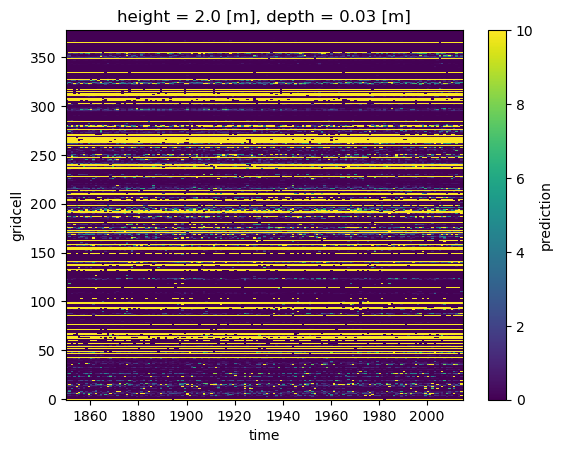

In [196]:
(test_skew_prediction_stacked.isel(depth=0).prediction**2 * test_var_prediction_stacked.isel(depth=0).prediction **3).clip(min=-10).clip(max=10).plot()

In [197]:
unstacked = mesmer.grid.unstack_lat_lon_and_align(test_skew_prediction_stacked,mrsol_masked_ds_for_mean)

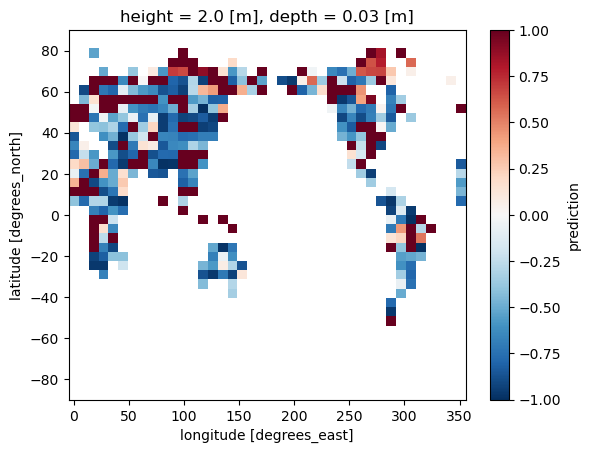

In [198]:
(np.abs(unstacked.isel(depth=0).mean("time").prediction)-1).clip(max=1).plot(x="lon")

### crps(s) Score

In [199]:
#temp
importlib.reload(model_analysis.crps_score);

scheinbar wächst die laufzeit in der ensemble_size mehr als linear, sieht schlimmer als quadratisch aus:(

5->0.5s

10->1.3s

20->4.2s

40->15s

80->1min 54s

In [200]:
crps_score_stacked, space_crps_score_stacked = model_analysis.crps_score.crps_ensemble_score(test_mean_prediction_stacked, test_var_prediction_stacked,test_target_ds_t,transformation="Log",ensemble_size=15)

/home/pjunghans/miniconda3/envs/mesmer-tests/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)
/home/pjunghans/miniconda3/envs/mesmer-tests/lib/python3.13/site-packages/properscoring/_crps.py:221: RuntimeWarning: invalid value encountered in subtract
  score = np.nanmean(weights * abs(forecasts - observations), -1)
/home/pjunghans/miniconda3/envs/mesmer-tests/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/pjunghans/miniconda3/envs/mesmer-tests/lib/python3.13/site-packages/properscoring/_crps.py:224: RuntimeWarning: invalid value encountered in subtract
  forecasts_diff = (np.expand_dims(forecasts, -1) -
/home/pjunghans/miniconda3/envs/mesmer-tests/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.r

for both of the scors we can calculate a crpss score against the time constant mean, for the score of the backtransposed data, we need to make a non-transposed target.

In [201]:
test_target_ds = model.transform.Log_Transform_ds_inv(test_target_ds_t)

/home/pjunghans/miniconda3/envs/mesmer-tests/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)


In [202]:
scores_stacked = model_analysis.crps_score.add_crpss_against_mean_ensemble_score(crps_score_stacked,test_target_ds) 

/home/pjunghans/miniconda3/envs/mesmer-tests/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [203]:
space_scores_stacked = model_analysis.crps_score.add_crpss_against_mean_ensemble_score(space_crps_score_stacked,test_target_ds_t) 

In [204]:
#scores

To visualize the results we bring it back to the lat lon grid form. Ausserdem entnehmen wir die Stellen wieder, die mit threshholds aufgefüllt wurden

In [205]:
scores = mesmer.grid.unstack_lat_lon_and_align(scores_stacked,mrsol_masked_ds_for_mean)
space_scores = mesmer.grid.unstack_lat_lon_and_align(space_scores_stacked,mrsol_masked_ds_for_mean)

In [206]:
scores = model.mask.mask_mask(scores,detail_mask_mean, "lon","lat", "depth")
space_scores = model.mask.mask_mask(space_scores,detail_mask_mean, "lon","lat", "depth")

Globale Score übersicht

Text(0.5, 1.0, 'crpss_score against const mean')

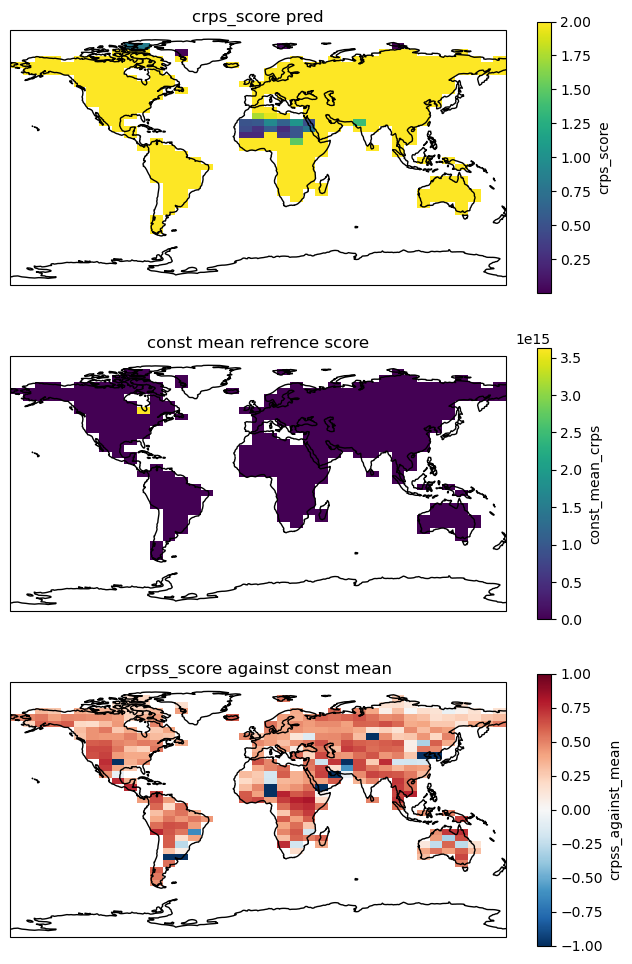

In [207]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=3,
    ncols=1,
    figsize=(8, 12)
)
depth = 0

da = scores.isel(depth=depth).mean("time").crps_score.clip(max=2)
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("crps_score pred")

da = scores.isel(depth=depth).mean("time").const_mean_crps
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("const mean refrence score")

da = scores.isel(depth=depth).mean("time").crpss_against_mean.clip(min=-1)
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("crpss_score against const mean")



Text(0.5, 1.0, 'space_crpss_score against const mean')

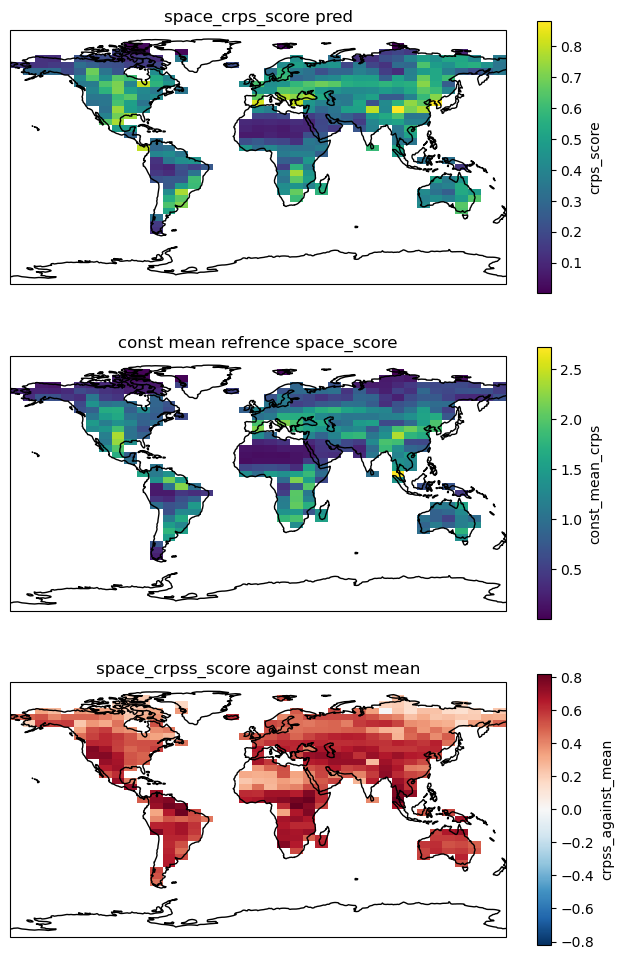

In [208]:
fig_global_space_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=3,
    ncols=1,
    figsize=(8, 12)
)

da = space_scores.isel(depth=0).mean("time").crps_score
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("space_crps_score pred")

da = space_scores.isel(depth=0).mean("time").const_mean_crps
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("const mean refrence space_score")

da = space_scores.isel(depth=0).mean("time").crpss_against_mean
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("space_crpss_score against const mean")



Locale Zeit reihe

In [209]:
#Amazonas  ca. 3° S, 65° W

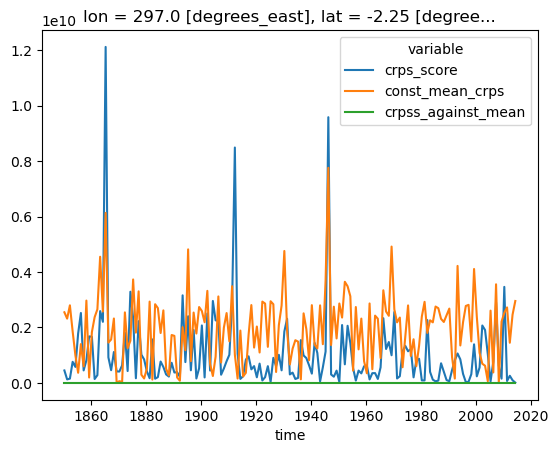

In [210]:
scores.sel(lat= -3, lon = 295, method="nearest").isel(depth = 0).to_array().plot.line(hue="variable", x = "time");

In [211]:
#irgendwo in Russland

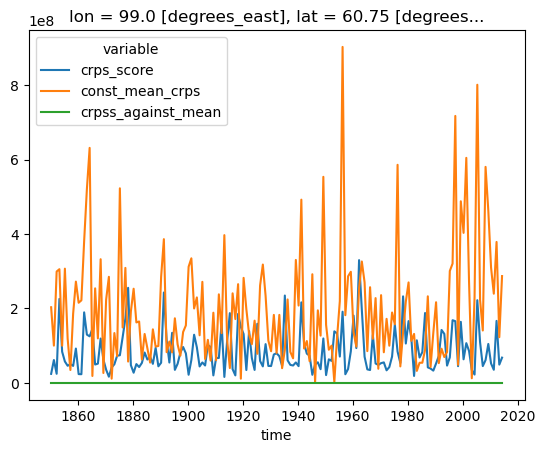

In [212]:
scores.sel(lat= 60, lon = 100, method="nearest").isel(depth = 0).to_array().plot.line(hue="variable", x = "time");

### Save results

In [213]:
if safe:
    model.save.save_crps_scores(scores, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Log_transform", name=f"month_idx = {month_idx}",name_postfix="back_transformed")
    model.save.save_crps_scores(scores, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Log_transform",name=f"month_idx = {month_idx}", name_postfix="space_score")
    model.save.save_plot(fig_global_crpss, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Log_transform", name = f"fig_global_crpss_clipped_month_idx = {month_idx}")
    model.save.save_plot(fig_global_space_crpss, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Log_transform", name = f"fig_global_space_crpss__month_idx = {month_idx}")